# 25 — Vanilla RNNs and Sequence Processing

A recurrent neural network processes an ordered sequence while carrying a hidden state from one time step to the next. This notebook develops the forward pass carefully before Notebook 26 introduces backpropagation through time.

## Learning objectives

- read and explain sequence tensor shapes;
- distinguish input features, time steps, and hidden features;
- implement one vanilla-RNN step;
- unroll the same recurrent parameters across a full sequence;
- distinguish many-to-one and many-to-many outputs;
- visualize how information persists through hidden states;
- handle padded time steps with a sequence mask.


In [49]:
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
generator = np.random.default_rng(SEED)


## 1. Sequence notation and shapes

We store a batch of sequences in a three-dimensional tensor

$$
X \in \mathbb{R}^{N \times T \times D},
$$

where:

- $N$ is the number of sequences in the batch;
- $T$ is the number of time steps per sequence;
- $D$ is the number of input features at each time step.

Indexing `X[:, t, :]` selects time step $t$ from every sequence, so its shape is $(N,D)$. An RNN produces hidden states

$$
H \in \mathbb{R}^{N \times T \times H_d},
$$

where $H_d$ is the hidden-state dimension. We use $H_d$ in equations here to avoid confusing the dimension with the full hidden-state tensor $H$.

The axes do not say what a sequence represents. The time axis could contain words, characters, audio frames, video frames, or another ordered signal.

### Exercise 1 — Identify the shapes

Complete the three expected shapes. Read each indexing operation axis by axis before running the assertions.


In [50]:
N, T, D, HIDDEN_DIM = 2, 4, 3, 5
X = generator.normal(size=(N, T, D))
h0 = generator.normal(size=(N, HIDDEN_DIM))

# replace None with the expected tuples.
one_time_step_shape = (N, D)            # X[:, 0, :].shape  # (2, 3)
one_sequence_shape = (T, D)             # X[0, :, :].shape  # (4, 3)
initial_hidden_shape = (N, HIDDEN_DIM)  # h0.shape          # (2, 5)

assert X[:, 2, :].shape == one_time_step_shape
assert X[0, :, :].shape == one_sequence_shape
assert h0.shape == initial_hidden_shape
print("Sequence batch shape:", X.shape)


Sequence batch shape: (2, 4, 3)


## 2. One recurrent step

At time $t$, a vanilla RNN combines the current input $x_t$ and previous hidden state $h_{t-1}$:

$$
a_t=x_tW_x+h_{t-1}W_h+b,
$$

$$
h_t=\tanh(a_t).
$$

The matrix dimensions are

$$
(N,D)(D,H_d)+(N,H_d)(H_d,H_d)+(H_d)=(N,H_d).
$$

NumPy broadcasts $b$ across the $N$ examples. $W_x$ maps the current input into hidden space, while $W_h$ transforms the previous hidden state. The `tanh` function keeps each new hidden value between $-1$ and $1$.

### Exercise 2 — Implement one RNN step

Implement the two equations directly. Cache the values needed by the backward pass we will write in Notebook 26.


In [51]:
def rnn_step_forward(x_t, h_previous, weights_x, weights_h, bias):
    """Compute one vanilla-RNN time step."""
    # compute the pre-activation and next hidden state.
    pre_activation = (
        x_t @ weights_x
        + h_previous @ weights_h
        + bias
    )
    h_t = np.tanh(pre_activation)
    cache = (x_t, h_previous, weights_x, weights_h, h_t)
    return h_t, cache


step_x = np.array([[1.0, -2.0], [0.5, 1.0]])
step_h_previous = np.array([[0.2, -0.1], [0.0, 0.3]])
step_weights_x = np.array([[0.5, -0.25], [1.0, 0.75]])
step_weights_h = np.array([[0.4, 0.2], [-0.5, 0.3]])
step_bias = np.array([0.1, -0.2])

step_h, step_cache = rnn_step_forward(
    step_x, step_h_previous, step_weights_x, step_weights_h, step_bias
)
expected_pre_activation = (
    step_x @ step_weights_x
    + step_h_previous @ step_weights_h
    + step_bias
)
np.testing.assert_allclose(step_h, np.tanh(expected_pre_activation))
assert step_h.shape == step_h_previous.shape
assert len(step_cache) == 5
print(step_h)


[[-0.85379765 -0.95953401]
 [ 0.83365461  0.47383179]]


## 3. Why the hidden state creates memory

The next hidden state depends on both $x_t$ and $h_{t-1}$. But $h_{t-1}$ already depends on $x_{t-1}$ and $h_{t-2}$. Repeated substitution shows that $h_t$ can indirectly depend on every earlier input.

This is a learned, compressed memory—not a perfect copy of the full past. Its behavior depends on $W_h$, the nonlinearity, and training.

### Exercise 3 — Separate current input from previous memory

Compute the two contributions before the bias and confirm that their sum produces the same hidden state as `rnn_step_forward`. Then briefly explain which term carries information from earlier time steps.


In [52]:
# calculate both contributions.
input_contribution = step_x @ step_weights_x
memory_contribution = step_h_previous @ step_weights_h
combined_hidden = np.tanh(input_contribution + memory_contribution + step_bias)

np.testing.assert_allclose(combined_hidden, step_h)
print("Input contribution:\n", input_contribution)
print("Memory contribution:\n", memory_contribution)

# Short answer: Which term carries information from earlier time steps?
# write your answer here.

# The memory contribution h_previous @ weights_h carries information from earlier time steps
# because h_previous was itself calculated from preceding inputs and hidden states.
# memory_contribution

Input contribution:
 [[-1.5   -1.75 ]
 [ 1.25   0.625]]
Memory contribution:
 [[ 0.13  0.01]
 [-0.15  0.09]]


## 4. Unrolling over a complete sequence

A sequence forward pass repeatedly calls the same step function:

$$
h_1=f(x_1,h_0),\quad h_2=f(x_2,h_1),\quad \ldots,\quad h_T=f(x_T,h_{T-1}).
$$

The loop is sequential along time because $h_t$ is required before $h_{t+1}$ can be computed. Different examples in the batch can still be processed together.

### Exercise 4 — Implement the sequence forward pass

Allocate an output tensor with shape $(N,T,H_d)$. Starting from `h0`, process `x[:, t, :]` at each time step, store the result, and carry it into the next step. Save one cache per time step.


In [53]:
def rnn_forward(x, h0, weights_x, weights_h, bias):
    """Run a vanilla RNN over an input with shape (N, T, D)."""
    # implement the time loop using rnn_step_forward.
    num_examples, num_steps, _ = x.shape
    hidden_dim = h0.shape[1]

    hidden_states = np.empty(
        (num_examples, num_steps, hidden_dim),
        dtype=np.result_type(x, h0, weights_x, weights_h, bias),
    )
    caches = []
    h_previous = h0

    for t in range(num_steps):
        x_t = x[:, t, :]
        h_t, cache = rnn_step_forward(
            x_t,
            h_previous,
            weights_x,
            weights_h,
            bias,
        )
        hidden_states[:, t, :] = h_t
        caches.append(cache)
        h_previous = h_t

    return hidden_states, caches


sequence_x = generator.normal(size=(2, 5, 3))
sequence_h0 = generator.normal(size=(2, 4))
sequence_weights_x = generator.normal(scale=0.3, size=(3, 4))
sequence_weights_h = generator.normal(scale=0.3, size=(4, 4))
sequence_bias = generator.normal(scale=0.1, size=4)

hidden_states, sequence_cache = rnn_forward(
    sequence_x,
    sequence_h0,
    sequence_weights_x,
    sequence_weights_h,
    sequence_bias,
)
assert hidden_states.shape == (2, 5, 4)
assert len(sequence_cache) == 5
first_h, _ = rnn_step_forward(
    sequence_x[:, 0, :],
    sequence_h0,
    sequence_weights_x,
    sequence_weights_h,
    sequence_bias,
)
np.testing.assert_allclose(hidden_states[:, 0, :], first_h)
print("Hidden-state sequence shape:", hidden_states.shape)


Hidden-state sequence shape: (2, 5, 4)


## 5. Parameter sharing through time

The same $W_x$, $W_h$, and $b$ are used at every time step. The RNN therefore learns one transition rule rather than a separate transformation for every sequence position.

For input dimension $D$ and hidden dimension $H_d$, the recurrent cell contains

$$
DH_d+H_d^2+H_d
$$

parameters, regardless of $T$. Without sharing, using an independent cell at every time step would multiply this count by $T$ and would not naturally generalize to new sequence lengths.

### Exercise 5 — Compare parameter counts


In [54]:
D, HIDDEN_DIM, T = 8, 16, 20

# calculate both counts.
shared_parameter_count = D * HIDDEN_DIM + HIDDEN_DIM**2 + HIDDEN_DIM
unshared_parameter_count = shared_parameter_count * T

assert shared_parameter_count == 400
assert unshared_parameter_count == 8000
print("Shared:", shared_parameter_count)
print("Separate parameters per step:", unshared_parameter_count)


Shared: 400
Separate parameters per step: 8000


## 6. Visualize hidden-state evolution

The following controlled sequence contains three consecutive input pulses at time steps 2, 3, and 4 and is zero everywhere else. During those three steps, each hidden state combines a new input with the previous state. After the final pulse, the input returns to zero, so any remaining nonzero hidden activation is carried forward through the recurrent connection.

Run the cell after completing Exercise 4. Then change the scale of `visual_weights_h` and observe how the hidden trajectory changes. This is an untrained illustrative system, not evidence that every trained hidden unit has a directly interpretable meaning.


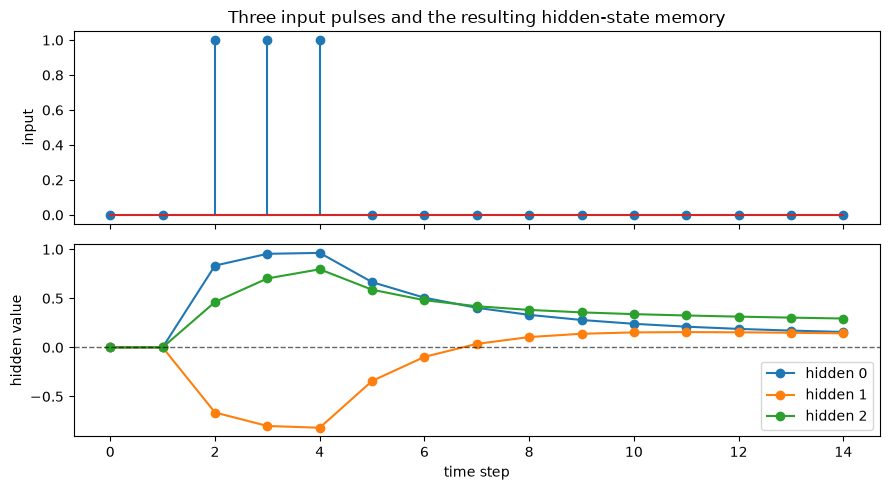

In [55]:
visual_x = np.zeros((1, 15, 1))
visual_x[0, 2:5, 0] = 1.0
visual_h0 = np.zeros((1, 3))
visual_weights_x = np.array([[1.2, -0.8, 0.5]])
visual_weights_h = np.array(
    [[0.75, 0.10, 0.00], [0.00, 0.65, 0.10], [0.10, 0.10, 0.95]]
)
visual_bias = np.zeros(3)
visual_hidden, _ = rnn_forward(
    visual_x, visual_h0, visual_weights_x, visual_weights_h, visual_bias
)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].stem(range(visual_x.shape[1]), visual_x[0, :, 0])
axes[0].set_ylabel("input")
axes[0].set_title("Three input pulses and the resulting hidden-state memory")
for hidden_index in range(visual_hidden.shape[2]):
    axes[1].plot(
        visual_hidden[0, :, hidden_index], marker="o", label=f"hidden {hidden_index}"
    )
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[1].set_xlabel("time step")
axes[1].set_ylabel("hidden value")
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Many-to-one and many-to-many outputs

The hidden-state sequence can support different tasks:

- **Many-to-one:** use the final hidden state to classify a complete sequence, such as classifying a video clip.
- **Many-to-many, aligned:** make one prediction per input step, such as labeling every video frame.
- **Encoder–decoder:** first encode an input sequence, then generate an output sequence, such as image captioning or translation.

A shared output projection can convert each hidden state into $C$ scores:

$$
S_{:,t,:}=H_{:,t,:}W_y+b_y.
$$

### Exercise 6 — Produce both output patterns


In [56]:
sequence_x.shape

(2, 5, 3)

- 2 independent sequences
- 5 time steps in each sequence
- 3 input features at every time step

In [57]:
hidden_states.shape

(2, 5, 4)

At every time step, the RNN converted the 3 input features into a hidden representation containing 4 features.

In [58]:
# produce one of six possible output scores
num_outputs = 6
output_weights = generator.normal(scale=0.2, size=(4, num_outputs))
output_bias = np.zeros(num_outputs)

# use all hidden states for aligned scores and only the final hidden
# state for one score vector per sequence. NumPy matmul handles the first
# two dimensions as batch dimensions.

# One set of scores at every time step.
aligned_scores = hidden_states @ output_weights + output_bias # Many-to-many output

# One set of scores for the complete sequence.
final_hidden = hidden_states[:, -1, :]
sequence_scores = final_hidden @ output_weights + output_bias # Many-to-one output

assert aligned_scores.shape == (2, 5, num_outputs)
assert sequence_scores.shape == (2, num_outputs)
np.testing.assert_allclose(sequence_scores, aligned_scores[:, -1, :])


## 8. Variable-length sequences and padding masks

A batch tensor needs one common value of $T$, but real sequences may have different lengths. Shorter sequences are padded. Padding is storage, not meaningful input, so the model should not update a completed sequence's state from padded positions.

At time $t$, let `valid[n]` say whether example $n$ still has a real input. A masked update is

$$
h_t^{(n)}=\begin{cases}
\widetilde{h}_t^{(n)} & \text{if step }t\text{ is valid},\\\\
h_{t-1}^{(n)} & \text{if step }t\text{ is padding},
\end{cases}
$$

where $\widetilde{h}_t$ is the candidate produced by the RNN cell.

### Exercise 7 — Preserve state across padded steps

Implement only the masking line. The recurrent candidate has already been calculated.

For example, if `lengths = [2, 4]`, then at `t = 2` the expression `t < lengths` produces `valid = [False, True]`: the first sequence has ended, while the second still contains a real input. Its shape is `(N,)`.

Both `candidate` and `h_previous` have shape `(N, H_d)`. We need one Boolean decision for each **row**, repeated across all $H_d$ hidden features in that row. `valid[:, None]` inserts a size-one axis and changes the shape from `(N,)` to `(N, 1)`. NumPy can then broadcast it across the hidden dimension:

```text
valid[:, None]     (N, 1)
candidate          (N, H_d)
h_previous         (N, H_d)
result             (N, H_d)
```

Use `np.where(condition, value_if_true, value_if_false)` to select the candidate row for a valid step and preserve the previous-state row for padding.


In [59]:
def rnn_forward_masked(x, h0, lengths, weights_x, weights_h, bias):
    """Run a forward RNN while preserving state after each sequence ends."""
    num_examples, num_steps, _ = x.shape
    hidden_dim = h0.shape[1]
    hidden_states = np.empty((num_examples, num_steps, hidden_dim))
    h_previous = h0

    for t in range(num_steps):
        candidate, _ = rnn_step_forward(
            x[:, t, :], h_previous, weights_x, weights_h, bias
        )
        # Comparing scalar t with lengths of shape (N,) gives one Boolean
        # per sequence: True for real input and False for padding.
        valid = t < lengths  # shape: (N,)

        # Add a size-one hidden-feature axis: (N,) -> (N, 1). This makes
        # each sequence's Boolean broadcast across all H_d hidden values.
        valid_by_hidden_feature = valid[:, None]  # shape: (N, 1)

        # candidate and h_previous both have shape (N, H_d). For each row,
        # take candidate when the step is valid; otherwise retain the
        # previous hidden state so padding cannot change the sequence.
        h_previous = np.where(
            valid_by_hidden_feature, candidate, h_previous
        )
        hidden_states[:, t, :] = h_previous

    return hidden_states


masked_x = generator.normal(size=(2, 4, 3))
lengths = np.array([2, 4])
masked_h = rnn_forward_masked(
    masked_x,
    np.zeros((2, 4)),
    lengths,
    sequence_weights_x,
    sequence_weights_h,
    sequence_bias,
)
np.testing.assert_allclose(masked_h[0, 2], masked_h[0, 1])
np.testing.assert_allclose(masked_h[0, 3], masked_h[0, 1])
assert not np.allclose(masked_h[1, 3], masked_h[1, 1])


## 9. Reflection

Write short answers in your own words.

1. What do $N$, $T$, $D$, and $H_d$ represent?
2. Why must $W_h$ have shape $(H_d,H_d)$?
3. In what sense does the hidden state act as memory?
4. Why does the recurrent parameter count not depend on sequence length?
5. Which part of the forward pass prevents all time steps from being computed independently at once?
6. What is the difference between many-to-one and aligned many-to-many prediction?
7. Why should padding not update a finished sequence's hidden state?
8. Does a vanilla RNN guarantee that information from a very early step will be preserved? Why not?

### Answers

1. N - number of sequences in the batch, T - number of time steps, D - nnumber of input features at each time step, H_d - number of features in each hidden state.
2. to calculate next hiddden state based on previous and keep dimension the same. The previous hidden state has shape $(N,H_d)$. Multiplication by $W_h$ must map it back into the same hidden space, so $W_h$ has shape $(H_d,H_d)$ and the result has shape $(N,H_d)$. It can then be added to the transformed input and bias.
3. to calculate new state we use previous. The current hidden state is calculated from both the current input and the previous hidden state. Because the previous state already depends on earlier states and inputs, the current state can act as a compressed summary of the sequence history.
4. the same parameters are used on each sequence step. The same $W_x$, $W_h$, and $b$ are reused at every time step. Increasing the sequence length increases the number of computations but does not create new recurrent parameters.
5. next step depend on previous result. Computing $h_t$ requires $h_{t-1}$, so the next time step cannot be evaluated until the preceding hidden state has been calculated.
6. Many-to-one uses the final hidden state to produce one prediction for the complete sequence. Aligned many-to-many uses every hidden state to produce one prediction at every time step.
7. Padding is not part of the original sequence. If padding updated the hidden state, artificial padding values could alter the representation after the real sequence had already ended.
8. No. Each new state compresses the previous state together with the current input. Repeated transformations and the saturating tanh activation can gradually weaken or overwrite early information. During training, gradients from distant steps can also vanish or explode.
